In [359]:
# Status: Not submitted, stage 3
import argparse
import matplotlib.pyplot as plt
import numpy as np

'''
astro specs for a hycean planet orbiting an m-dwarf:
    P = 38.5 days
    Mp = 10.4 earth masses
    Ms = 0.25 solar masses for m-dwarf
    Dp = 2.3 g/cm^3 (density)
'''

'\nastro specs for a hycean planet orbiting an m-dwarf:\n    P = 38.5 days\n    Mp = 10.4 earth masses\n    Ms = 0.25 solar masses for m-dwarf\n    Dp = 2.3 g/cm^3 (density)\n'

In [378]:
P = 28.2 * 24 # orbital period in hours
Rp = 2.6 * 0.00916 # planet radius in solar radii
Rs = 0.25 # star radius in solar radii
Tobs = 8 # observation window in hours
e = 0.3 # orbital eccentricity
dt = 0.1 # time step in hours

def transit(P, Rp, Rs, e, dt): # define transit simulation function
    # P = orbital period
    # Rp = planet radius
    # Rs = star radius
    # e = orbit eccentricity (e >= 0)
    # dt = time step / sampling rate
    
    t = np.arange(0, P, dt) # time array spanning one full orbital period
    brightness = np.ones(len(t)) # flat baseline brightness of 1
    depth = Rp / Rs # fractional brightness drop during transit

    choice = input("Choose viewing point (a, b, c, d): ") # prompt user for viewing angle
    if choice == 'a': # periastron
        omega = 0
    elif choice == 'b': # 90 degrees from periastron
        omega = np.pi / 2
    elif choice == 'c': # apastron
        omega = np.pi
    elif choice == 'd': # 270 degrees from periastron
        omega = 3 * np.pi / 2
    else: # default to periastron if invalid choice
        print("Invalid choice, defaulting to periastron")
        omega = 0

    Rs_m = Rs * 6.957e8 # star radius in meters
    rho = 56000 # stellar density in kg/m^3 for an m-dwarf
    Ms = (4/3) * np.pi * Rs_m**3 * rho # stellar mass from density and radius
    G = 6.674e-11 # gravitational constant in m^3 kg^-1 s^-2
    P_s = P * 3600 # orbital period in seconds
    a = ((G * Ms * P_s**2) / (4 * np.pi**2))**(1/3) # semi-major axis from Keplers third law
    b = 0 # impact parameter, 0 = central transit
    Tdur = ((P_s * Rs_m) / (np.pi * a)) * (np.sqrt(1 - b**2) / np.sqrt(1 - e**2)) * (1 / (1 + e * np.sin(omega))) # transit duration in seconds
    Tdur_hr = Tdur / 3600 # transit duration in hours

    t_center = P / 2 # place transit dip at center of time array
    for i in range(len(t)): # loop over every time step
        if abs(t[i] - t_center) < Tdur_hr / 2: # if within transit duration
            brightness[i] -= depth # apply brightness drop

    return t, brightness # return time array and brightness signal

t, og_signal = transit(P, Rp, Rs, e, dt) # run transit simulation

Choose viewing point (a, b, c, d):  a


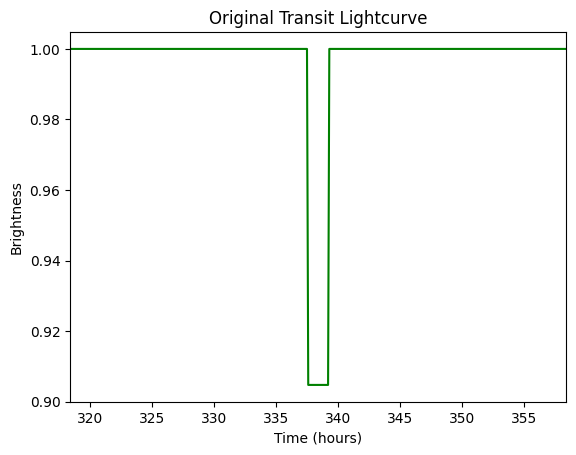

In [375]:
plt.plot(t, og_signal, color="green")
plt.title("Original Transit Lightcurve") 
plt.xlim(P/2 - 20, P/2 + 20)
plt.xlabel("Time (hours)") # x axis label
plt.ylabel("Brightness") # y axis label
plt.show() # display plot


### Creating Noise, Showing Noisy Dips

In [376]:
# creating gaussian noise at different noise levels
np.random.seed(9) # save results
n_signals = []
n_lvl_list = [0.01, 0.05, 0.1, 0.2] # list of noise levels to measure how increasing noise affects my ability to recover the signal
for n_lvl in n_lvl_list:
    noise = np.random.normal(0, n_lvl, size=len(og_signal)) # normal means random gaussian
    n_signal = og_signal + noise # new noisy signal
    n_signals.append(n_signal)
print(n_signals)

[array([1.00001109, 0.99710456, 0.98883934, ..., 0.99877559, 1.00252159,
       0.99635092]), array([0.96384254, 1.0073168 , 0.98552628, ..., 0.95564424, 0.96899867,
       0.96325102]), array([0.97182359, 1.12224573, 0.99723307, ..., 1.03012026, 0.94195612,
       1.03066889]), array([1.3935544 , 0.74360977, 1.26188393, ..., 1.08739647, 0.98278997,
       1.0011101 ])]


### Masking Data

In [363]:
# masking (deleting) some data randomly
missing_frac = 0.3
obs_signals = []
for n_sig in n_signals:
    obs = np.copy(n_sig)
    mask = np.random.rand(len(obs)) > missing_frac
    obs[~mask] = np.nan
    obs_signals.append(obs)


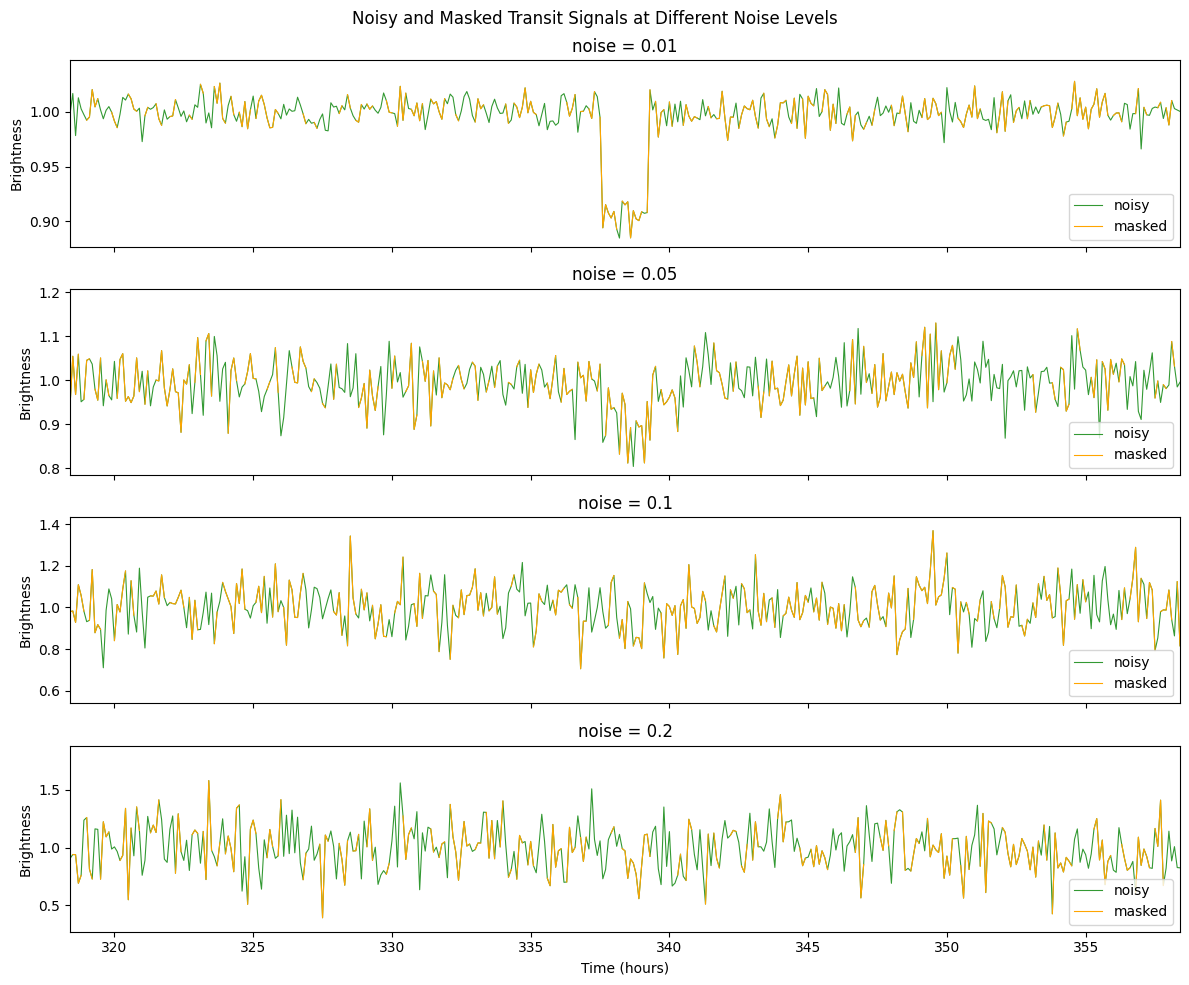

In [364]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
labels = ['noise = 0.01', 'noise = 0.05', 'noise = 0.1', 'noise = 0.2']

for i in range(len(obs_signals)):
    obs = np.copy(obs_signals[i])
    mask = np.random.rand(len(obs)) > missing_frac
    obs[~mask] = np.nan

    axes[i].plot(t, n_signals[i], linewidth=0.8, alpha=0.8, label="noisy", color="green")
    axes[i].plot(t, obs_signals[i], linewidth=0.8, label="masked", color="orange")
    axes[i].set_ylabel("Brightness")
    axes[i].set_title(labels[i])
    axes[i].set_xlim(P/2 - 20, P/2 + 20)
    axes[i].legend(loc="lower right")

axes[-1].set_xlabel("Time (hours)")
plt.suptitle("Noisy and Masked Transit Signals at Different Noise Levels")
plt.tight_layout()
plt.show()

### Recovering with Fourier Transform (DFT)

In [379]:
def fourier(signal): # define manual DFT function
    N = len(signal) # number of data points
    c = np.zeros(N, dtype=complex) # empty array to store frequency coefficients
    for k in range(N): # loop over each frequency component
        for n in range(N): # loop over each time step
            c[k] += signal[n] * np.exp(-2j * np.pi * k * n / N) # compute frequency coefficient
    return c # return frequency coefficients

def inverse_dft(c): # define manual inverse DFT function
    N = len(c) # number of frequency components
    y = np.zeros(N, dtype=complex) # empty array to store recovered signal
    for n in range(N): # loop over each time step
        for k in range(N): # loop over each frequency component
            y[n] += c[k] * np.exp(2j * np.pi * k * n / N) # reconstruct signal from frequency components
        y[n] /= N # normalize by number of points
    return y # return recovered signal

##### Fourier Transform using the functions; They take too long to run

In [366]:
# apply fourier transforms to each obs_signal -> rec_signals
rec_signals = [] # empty list to store recovered signals
for obs in obs_signals: # loop over each observed signal
    t_idx = np.arange(len(obs)) # create index array for interpolation
    valid = ~np.isnan(obs) # find indices where signal is not NaN
    obs_interp = np.interp(t_idx, t_idx[valid], obs[valid]) # interpolate over NaN gaps before DFT
    c = fourier(obs_interp) # apply DFT to get frequency coefficients
    rec = inverse_dft(c).real # apply inverse DFT to recover signal, take real part
    rec_signals.append(rec) 

N = len(rec_signals[0]) 

KeyboardInterrupt: 

##### Fourier Transform using np.fft; These run much faster

In [367]:
# apply fourier transforms to each obs_signal -> rec_signals
rec_signals = [] # empty list to store recovered signals
for obs in obs_signals: # loop over each observed signal
    t_idx = np.arange(len(obs)) # create index array for interpolation
    valid = ~np.isnan(obs) # find indices where signal is not NaN
    obs_interp = np.interp(t_idx, t_idx[valid], obs[valid]) # interpolate over NaN gaps before DFT
    c = np.fft.fft(obs_interp) # apply DFT to get frequency coefficients
    rec = np.fft.ifft(c).real # apply inverse DFT to recover signal, take real part
    rec_signals.append(rec) # store recovered signal

N = len(rec_signals[0]) # store signal length for use in later cells

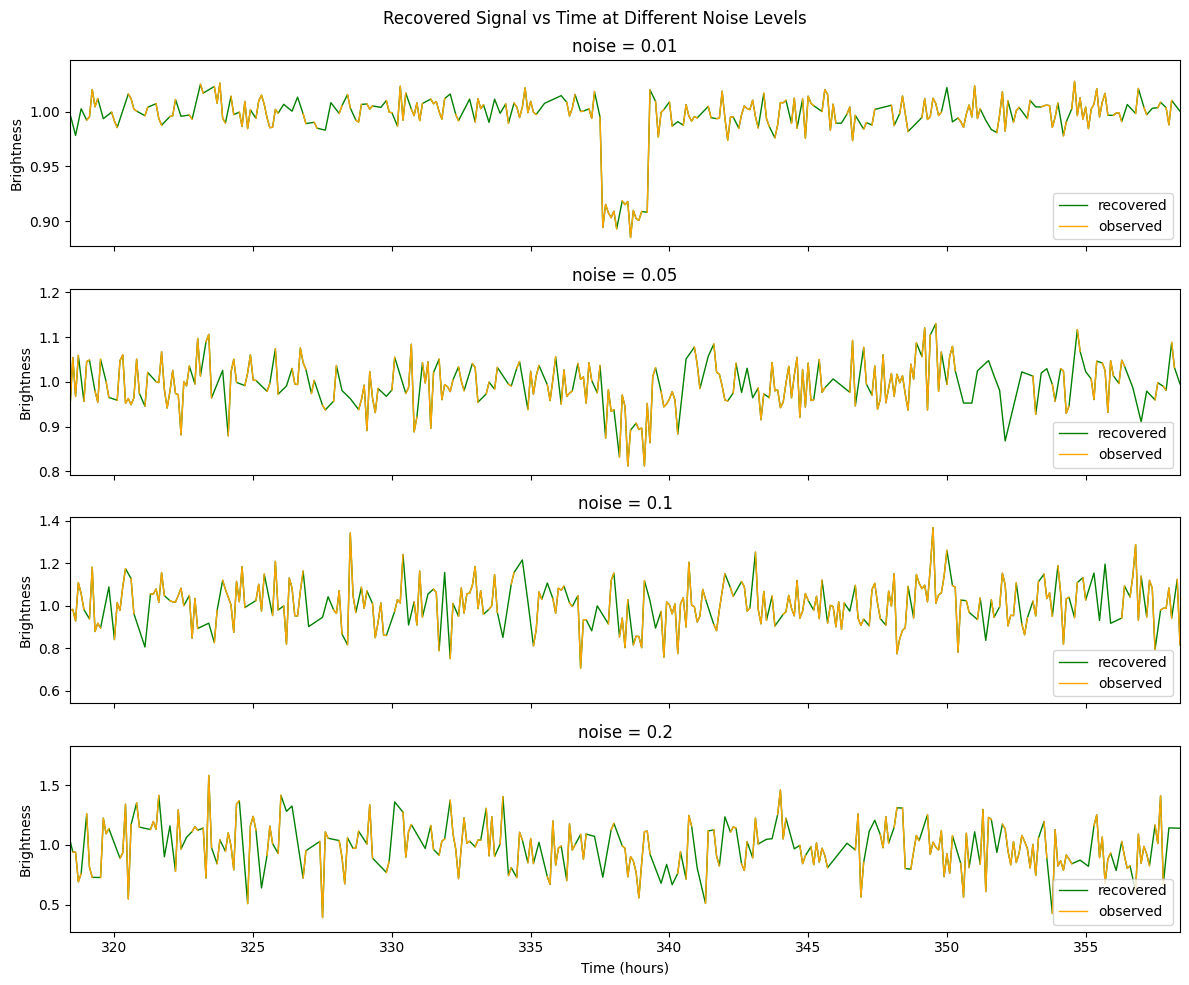

In [368]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True) # create 4 subplots
labels = ['noise = 0.01', 'noise = 0.05', 'noise = 0.1', 'noise = 0.2'] # noise level labels

for i in range(len(rec_signals)): # loop over each recovered signal
    axes[i].plot(t, rec_signals[i], linewidth=1, color="green", label="recovered") # plot recovered signal
    axes[i].plot(t, obs_signals[i], linewidth=1, color="orange", label="observed") # plot observed signal
    axes[i].set_ylabel("Brightness") # y axis label
    axes[i].set_title(labels[i]) # subplot title
    axes[i].set_xlim(P/2 - 20, P/2 + 20) # zoom around transit dip
    axes[i].legend(loc="lower right") # add legend

axes[-1].set_xlabel("Time (hours)") # x axis label on bottom subplot
plt.suptitle("Recovered Signal vs Time at Different Noise Levels") # overall title
plt.tight_layout() # adjust spacing
plt.show() # display plot

### Feature Extraction from Recovered Signal

##### Period, Transit Depth, Signal-to-Noise Ration(SNR), Detection Confidence

In [369]:
import pandas as pd # import pandas for table display

rows = [] # empty list to store feature rows

for i in range(len(rec_signals)): # loop over each recovered signal
    rec = rec_signals[i] # get recovered signal

    est_period = N * dt # estimated period is total signal length

    baseline = np.median(rec[rec > np.percentile(rec, 50)]) # median of out-of-transit points
    est_depth = baseline - np.min(rec) # depth is baseline minus minimum

    out_of_transit = rec[rec > np.percentile(rec, 50)] # out-of-transit points
    noise_std = np.std(out_of_transit) # noise is std of out-of-transit points
    snr = est_depth / noise_std # signal-to-noise ratio

    confidence_pct = min(100.0, (snr / 5.0) * 100) # detection confidence scaled to SNR of 5

    rows.append({ # append row to list
        'Noise Level': n_lvl_list[i], # noise level
        'Est. Period (hrs)': round(est_period, 2), # estimated period
        'True Period (hrs)': round(P, 2), # true period
        'Est. Depth': round(est_depth, 4), # estimated depth
        'True Depth': round(Rp/Rs, 4), # true depth
        'SNR': round(snr, 2), # signal-to-noise ratio
        'Confidence (%)': round(confidence_pct, 1) # detection confidence
    })

df = pd.DataFrame(rows) # create dataframe from rows
print(df.to_string(index=False)) # print table without index

 Noise Level  Est. Period (hrs)  True Period (hrs)  Est. Depth  True Depth   SNR  Confidence (%)
        0.01              676.8              676.8      0.1213      0.0953 20.97           100.0
        0.05              676.8              676.8      0.2181      0.0953  7.62           100.0
        0.10              676.8              676.8      0.4820      0.0953  8.35           100.0
        0.20              676.8              676.8      0.7745      0.0953  6.96           100.0


### Optimization: Making a Best Fit Model

In [370]:
from scipy.optimize import minimize # import minimize function

def transit_model(params, t): # define transit model function
    depth, t_center, duration = params # unpack parameters
    model = np.ones(len(t)) # start with flat baseline
    for i in range(len(t)): # loop over time array
        if abs(t[i] - t_center) < duration / 2: # if within transit duration
            model[i] -= depth # apply depth to model
    return model # return model

def error_func(params, t, rec): # define error function
    return np.sum((rec - transit_model(params, t))**2) # sum of squared residuals between rec_signal and model



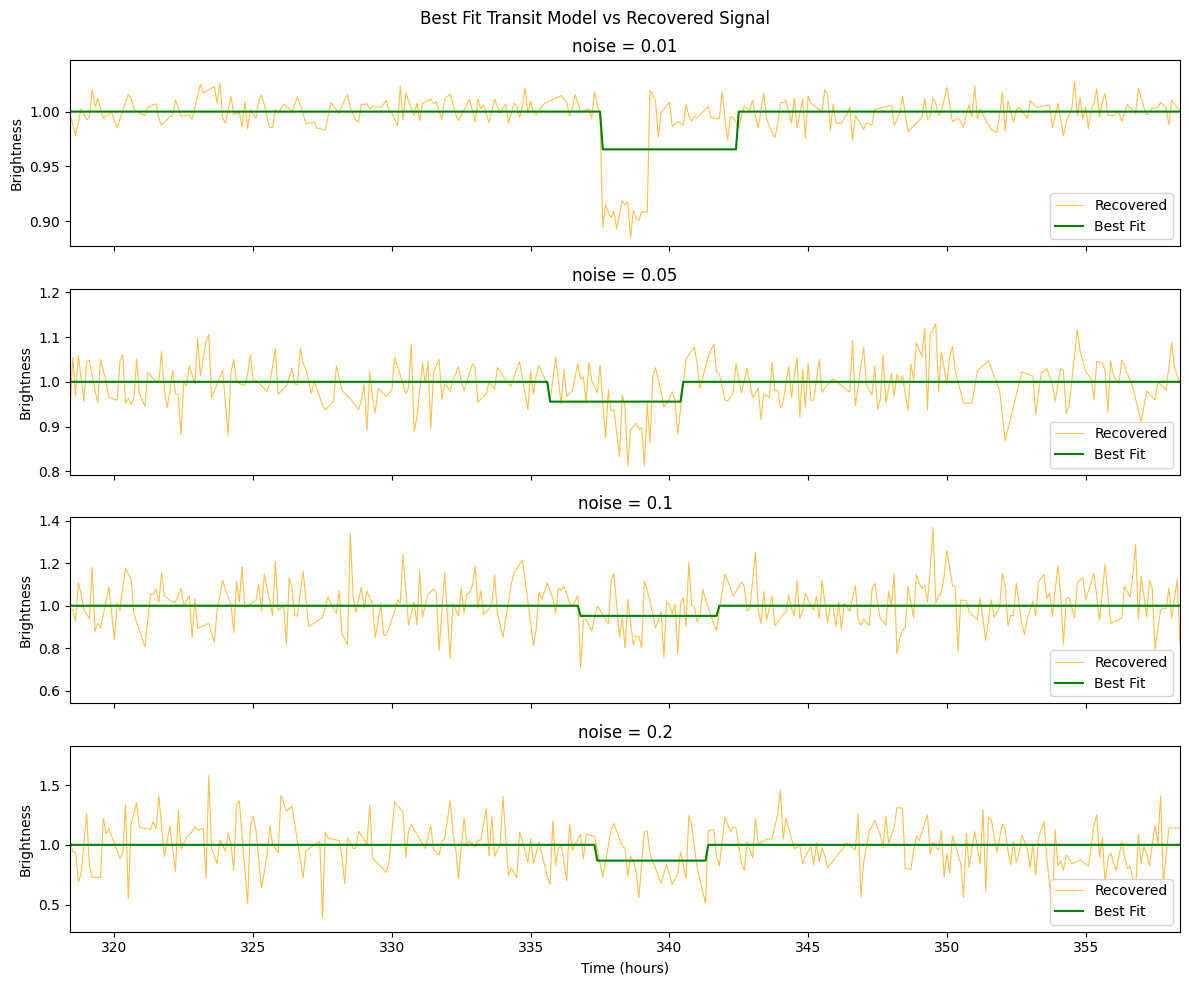

In [371]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True) # create 4 subplots
labels = ['noise = 0.01', 'noise = 0.05', 'noise = 0.1', 'noise = 0.2'] # noise level labels

for i in range(len(rec_signals)): # loop over each recovered signal
    rec = rec_signals[i] # get recovered signal
    result = minimize(error_func, [Rp/Rs, P/2, 5.0], args=(t, rec), method='Powell') # minimize error function
    best_model = transit_model(result.x, t) # get best fit model

    axes[i].plot(t, rec_signals[i], label="Recovered", color="orange", linewidth=0.8, alpha=0.7) # plot recovered signal
    axes[i].plot(t, best_model, label="Best Fit", color="green", linewidth=1.5) # plot best fit model
    axes[i].set_xlim(P/2 - 20, P/2 + 20) # zoom around transit dip
    axes[i].set_ylabel("Brightness") # y axis label
    axes[i].set_title(labels[i]) # subplot title
    axes[i].legend(loc="lower right") # add legend

axes[-1].set_xlabel("Time (hours)") # x axis label on bottom subplot
plt.suptitle("Best Fit Transit Model vs Recovered Signal") # overall title
plt.tight_layout() # adjust spacing
plt.show() # display plot

### Error Calculation

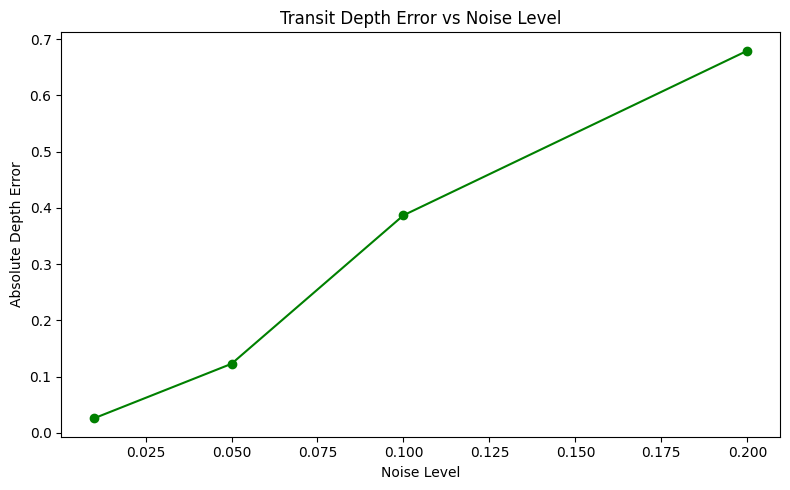

In [372]:
depth_errors = [] # empty list to store depth errors

for i in range(len(rec_signals)): # loop over each recovered signal
    rec = rec_signals[i] # get recovered signal
    baseline = np.median(rec[rec > np.percentile(rec, 50)]) # median of out-of-transit points
    est_depth = baseline - np.min(rec) # estimated depth
    depth_errors.append(abs(est_depth - (Rp / Rs))) # append absolute depth error

plt.figure(figsize=(8, 5)) # create figure
plt.plot(n_lvl_list, depth_errors, marker='o', color='green') # plot depth error vs noise level
plt.title("Transit Depth Error vs Noise Level") # title
plt.xlabel("Noise Level") # x axis label
plt.ylabel("Absolute Depth Error") # y axis label
plt.tight_layout() # adjust spacing
plt.show() # display plot

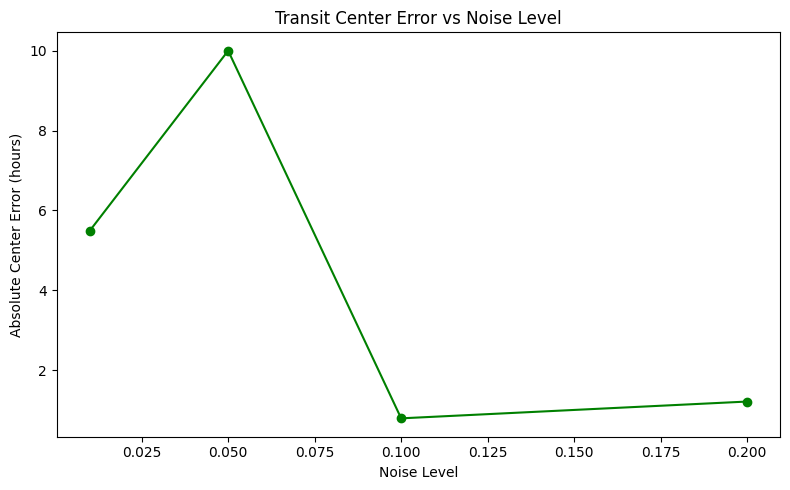

In [374]:
center_errors = [] # empty list to store center errors

for i in range(len(rec_signals)): # loop over each recovered signal
    rec = rec_signals[i] # get recovered signal
    result = minimize(error_func, [Rp/Rs, P/2, 5.0], args=(t, rec), method='Powell', # minimize error function
                      bounds=[(0, 1), (P/2 - 10, P/2 + 10), (0.1, 20)]) # constrain parameters
    best_t_center = result.x[1] # get best fit center time
    center_errors.append(abs(best_t_center - P/2)) # append absolute center error vs true center

plt.figure(figsize=(8, 5)) # create figure
plt.plot(n_lvl_list, center_errors, marker='o', color='green') # plot center error vs noise level
plt.title("Transit Center Error vs Noise Level") # title
plt.xlabel("Noise Level") # x axis label
plt.ylabel("Absolute Center Error (hours)") # y axis label
plt.tight_layout() # adjust spacing
plt.show() # display plot